In [4]:
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
sys.path.append("/Users/ana/Desktop/takarada/")
from helpers_takarada import * 
from module_takarada import *
import matplotlib
import seaborn as sns
plt.rcParams.update({'savefig.dpi':300, 'axes.labelweight':'normal'})
matplotlib.rcParams['axes.linewidth'] = 0.8
from matplotlib import rc
preamble = r'''\usepackage{physics} \usepackage{upgreek} \usepackage{bm}'''
plt.rc('text.latex', preamble=preamble)
rc('text', usetex=True)

plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 15
plt.rcParams['ytick.labelsize'] = 15
plt.rcParams['axes.titlesize'] = 15
plt.rcParams['figure.figsize'] = (6,4)
plt.rcParams['legend.fontsize'] = 12

''' numerical parameters for the self-consistent calculation '''
parameters1 = {'n_pass' : 1e-4,
'epsilon_threshold' : 1e-6,
'N_epsilon' : 5,
'maxiter' : 500,
'eps_last' : 1e-6,
'dmu' : 0.1,
'mix2' : 0.001,
'mix3' : 1.5,
'faktor1' : 0.1,
'max_trials' : 15,
'eps0' : 0.03,
}

parameters2 = {'n_pass' : 1e-4,
'epsilon_threshold' : 1e-6,
'N_epsilon' : 5,
'maxiter' : 500,
'eps_last' : 1e-6,
'dmu' : 0.1,
'mix2' : 0.001,
'mix3' : 1.5,
'faktor1' : 0.1,
'max_trials' : 15,
'eps0' : 0.03,
}

def colorFader(c1, c2, mix=0.5):
    c1 = np.array(matplotlib.colors.to_rgb(c1))
    c2 = np.array(matplotlib.colors.to_rgb(c2))
    return matplotlib.colors.to_hex((1-mix)*c1 + mix*c2)

def get_palette_hex(palette_name, N):
    return sns.color_palette(palette_name, n_colors=N).as_hex()

delta_b = 0.248
delta_c = 0.055
gap = 1.073


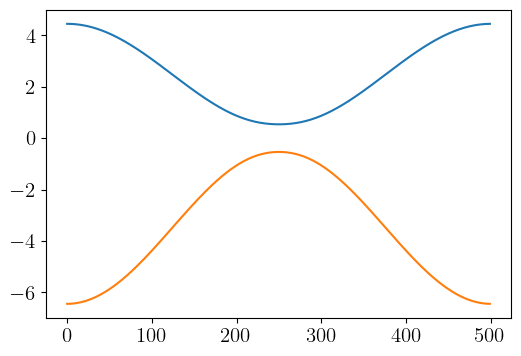

In [14]:
''' 1. generate ground state of some excitonic insulator model '''
a = 1.
b = 0.2

t12 = 0.0
delta = 0.0

t = 1.5
t_ = 1.0
Vb = 3.0
Vc = 1.0

mu0 = 0.
include_hartree = True

Nk = 500

epsilon = 1.0
epsilon_ = 1.0

phys_parameters = [b, t, t_, t12, epsilon, epsilon_, Vb, Vc, delta]
m = model(Nk, mu0, phys_parameters, parameters1, parameters2, include_hartree)
m.GS()
plt.plot(m.energije[1]-m.mu)
plt.plot(m.energije[0]-m.mu)
print(f'delta_b = {np.round(np.abs(m.delta_b), 3)}')
print(f'delta_c = {np.round(np.abs(m.delta_c), 3)}')
print(f'gap = {np.round(m.gap, 3)}')

In [15]:
''' 2. temperature sweep '''
beta0 = 20 * 1 / m.gap
scale = 1.005
betas = beta0/scale**np.arange(1,80)
betafreq = 1
stops = [int(np.emath.logn(scale, beta0/beta)) for beta in betas][::betafreq]
Ts = 1/betas
maxbrentq = 10

# set parameters below to random values, because I will not compute transport coefficients in this temperature sweep
Gammas = [0.005]
params = {'Nomega' : 1500, 'eps' : 1e-5, 'L' : 1000, 'deg' : 5000, 'omega0' : 1e-3, 'scale' : 10, 'eps2' : 1e-3}

m.run_Tdependence(betas, stops, Gammas, params, maxbrentq, evaluate_transport_DC=True, evaluate_vertex_DC=True)

started
0.0
18.542573258806787 9.95827997951615e-07 0.9999999954823812 -0.25120454849820284 -0.05613614829395326
0.012658227848101266
18.45032165055402 9.978024477219627e-07 1.0000000013882255 -0.251200969336671 -0.056135352363030085
-----
1.0
7226.181158068533
0.016350589517738958
0.02531645569620253
18.35852900552639 9.964917254690064e-07 0.9999999952151056 -0.2511970975240547 -0.056134492063346045
-----
1.0
6990.358991025885
0.01656797204983117
0.0379746835443038
18.267193040324766 9.96846562406617e-07 0.9999999950779828 -0.25119310527989824 -0.05613360464823459
0.05063291139240506
18.17631148291022 9.986157134544982e-07 1.000000001309147 -0.2511889764518292 -0.05613268657892409
-----
1.0
6440.32310735366
0.016592973978352084
0.06329113924050633
18.08588207254748 9.976053110816174e-07 0.9999999947966297 -0.251184549778601 -0.05613170288158475
0.0759493670886076
17.99590255974874 9.99220164332737e-07 1.0000000012448538 -0.25118001540169194 -0.056130694697147356
-----
1.0
5969.5578467

KeyboardInterrupt: 

In [7]:
def collect_data(self):
    data = {"delta_bs": np.array(self.delta_bs),
            "delta_cs": np.array(self.delta_cs),
            "ns0": np.array(self.ns0),
            "ns1": np.array(self.ns1),
            "gaps": np.array(self.gaps),
            "mus": np.array(self.mus),
            "errors": np.array(self.errors),
            "occupations": np.array(self.occupations),
            "Ts": np.array(self.Ts),
            "mean_energies": np.array(self.mean_energies),
            "L11": np.array(self.L11),
            "L12": np.array(self.L12),
            "L22" : np.array(self.L22),
            "L12q": np.array(self.L12q),
            "L11_boltz": np.array(self.L11_boltz),
            "L12_boltz": np.array(self.L12_boltz),
            "L22_boltz": np.array(self.L22_boltz),
            "L11_0": np.array(self.L11_0),
            "L11_corr": np.array(self.L11_corr),
            "L12_0": np.array(self.L12_0),
            "L12_corr": np.array(self.L12_corr),
            "L12q_0": np.array(self.L12q_0),
            "L12q_corr": np.array(self.L12q_corr),
            "phys_parameters" : np.array(self.phys_parameters),
            "Gammas": self.Gammas,
            "include_hartree" : self.include_hartree}
    return data

In [8]:
data = collect_data(m)

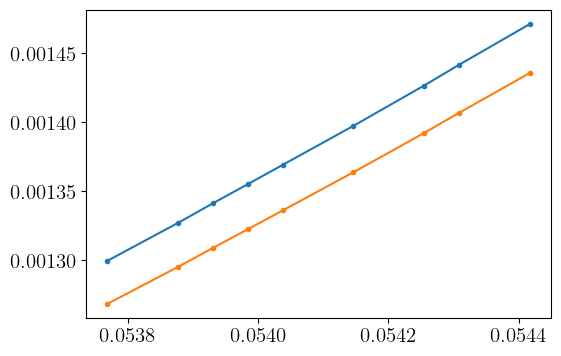

(-0.1, 0.1)

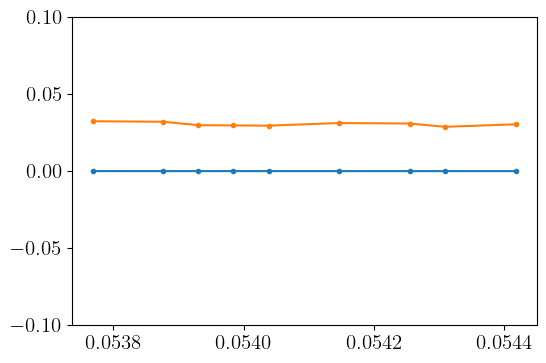

In [13]:
g = 0
plt.plot(m.Ts, data['L11_0'], '.-')
plt.plot(m.Ts, data['L11_corr'], '.-')
#plt.plot(data['Ts'],data['L12_corr'][:,g])
plt.show()

plt.plot(m.Ts, data['L12_0'], '.-')
plt.plot(m.Ts, data['L12_corr'], '.-')
plt.ylim(-0.1,0.1)


In [9]:
''' 2. heat up to a low temperature '''
beta0 = 50
scale = 1.005
betas = beta0/scale**np.arange(1,8)
stops = [int(np.emath.logn(scale, beta0/beta)) for beta in betas]
Ts = 1/betas
maxbrentq = 20

# set parameters below to random values, because I will not compute transport coefficients in this temperature sweep
Gammas = [0.005]
params = {'Nomega' : 1000, 'eps' : 1e-5, 'L' : 1000, 'deg' : 5000, 'omega0' : 1e-2, 'scale' : 5, 'eps2' : 1e-5}


m.run_Tdependence(betas, stops, Gammas, params, maxbrentq, evaluate_transport_DC=True, evaluate_vertex_DC=True)

started
0.0


KeyboardInterrupt: 

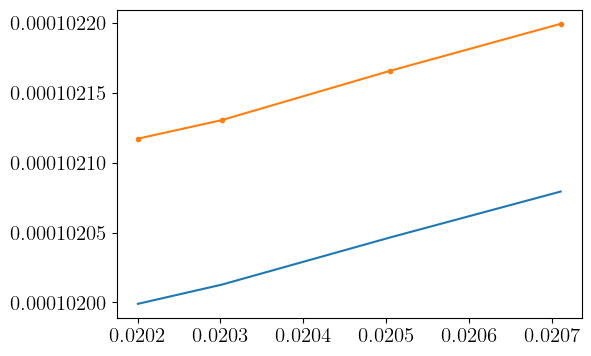

In [5]:
plt.plot(m.Ts, m.L11_0)
plt.plot(m.Ts, m.L11_corr, '.-')

In [45]:
rhos = m.rhos
tok = m.tok

''' 3. simulate pulz for excitonic susceptibility '''
perturbation_operator = rhos[2]
measure_provider = [rhos[0], rhos[1], rhos[2], rhos[3]]

A0 = 0.003
t0 = 2.0
sigma = 0.01
Omega0 = 0.0
dt = 0.004
t_max = 350
Ncorr = 100
tol = 1e-5

Gamma = 0.0

do_freeze = True
time, measurement, norma, delta_bs, delta_cs = simulate_pulz(m.K, m.hk0, m.rho, m.phys_parameters, m.include_hartree, perturbation_operator, measure_provider,
                                                             A0, t0, sigma, Omega0, dt, t_max, do_freeze, Ncorr, tol, m.geom, m.phases, m.g_ffts, Gamma)

do_freeze = False
timeN, measurementN, normaN, delta_bsN, delta_csN = simulate_pulz(m.K, m.hk0, m.rho, m.phys_parameters, m.include_hartree, perturbation_operator, measure_provider,
                                                             A0, t0, sigma, Omega0, dt, t_max, do_freeze, Ncorr, tol, m.geom, m.phases, m.g_ffts, Gamma)


''' 4. simulate pulz with current '''
perturbation_operator = tok
measure_provider = tok

do_freeze = True
timeJ, measurementJ, normaJ, delta_bsJ, delta_csJ = simulate_pulz(m.K, m.hk0, m.rho, m.phys_parameters, m.include_hartree, perturbation_operator, measure_provider,
                                                             A0, t0, sigma, Omega0, dt, t_max, do_freeze, Ncorr, tol, m.geom, m.phases, m.g_ffts, Gamma)

do_freeze = False
timeNJ, measurementNJ, normaNJ, delta_bsNJ, delta_csNJ = simulate_pulz(m.K, m.hk0, m.rho, m.phys_parameters, m.include_hartree, perturbation_operator, measure_provider,
                                                             A0, t0, sigma, Omega0, dt, t_max, do_freeze, Ncorr, tol, m.geom, m.phases, m.g_ffts, Gamma)

0.0
0.0005714285714285715
0.001142857142857143
0.0017142857142857142
0.002285714285714286
0.002857142857142857
0.0034285714285714284
0.004
0.004571428571428572
0.005142857142857143
0.005714285714285714
0.006285714285714286
0.006857142857142857
0.0074285714285714285
0.008
0.008571428571428572
0.009142857142857144
0.009714285714285713
0.010285714285714285
0.010857142857142857
0.011428571428571429
0.012
0.012571428571428572
0.013142857142857144
0.013714285714285714
0.014285714285714285
0.014857142857142857
0.015428571428571429
0.016
0.01657142857142857
0.017142857142857144
0.017714285714285714
0.018285714285714287
0.018857142857142857
0.019428571428571427
0.02
0.02057142857142857
0.021142857142857144
0.021714285714285714
0.022285714285714287
0.022857142857142857
0.023428571428571427
0.024
0.02457142857142857
0.025142857142857144
0.025714285714285714
0.026285714285714287
0.026857142857142857
0.027428571428571427
0.028
0.02857142857142857
0.029142857142857144
0.029714285714285714
0.03028571

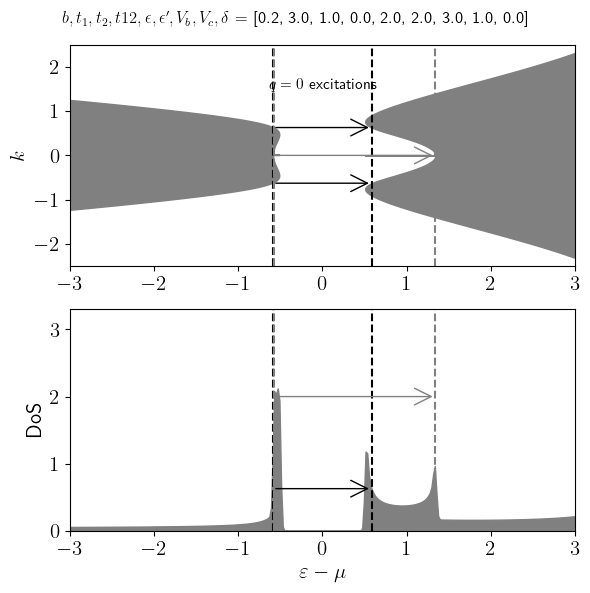

In [46]:
epsilons = np.linspace(-3,3,300)
tok_tilde = operator_tilde(m.tok, m.vecs)
dos = DoS(m.K, m.energije, epsilons, m.mu, tok_tilde, 1.0)

fig, ax = plt.subplots(nrows=2, figsize=(6,6))
gap = np.min(m.energije[1]) - np.max(m.energije[0])

ax[0].fill_between(m.energije[0] - m.mu, m.K, color='grey')
ax[0].fill_between(m.energije[1] - m.mu, m.K, color='grey')
ax[1].fill_between(epsilons, np.zeros(epsilons.shape), dos[0], color='grey')
ax[1].fill_between(epsilons, np.zeros(epsilons.shape), dos[1], color='grey')

import scipy
vrh1 = epsilons[scipy.signal.argrelextrema(dos[0], np.greater)]
vrh2 = epsilons[scipy.signal.argrelextrema(dos[1], np.greater)]

ind = np.argmin(np.abs(m.energije[1] - m.energije[0]))
k0 = m.K[ind]
dE_1 = m.energije[1,ind] - m.energije[0,ind]
dE_2 = m.energije[1,m.Nk//2] - m.energije[0,m.Nk//2]

for j in range(2):
    ax[j].axvline(m.energije[0,ind] - m.mu, ls='dashed', color='black')
    ax[j].axvline(m.energije[1,ind] - m.mu, ls='dashed', color='black')
    ax[j].axvline(m.energije[0,m.Nk//2] - m.mu, ls='dashed', color='grey')
    ax[j].axvline(m.energije[1,m.Nk//2] - m.mu, ls='dashed', color='grey')
    ax[j].annotate(
        "",                 # no text
        xy=(m.energije[0,ind] - m.mu, k0),           # arrow tip
        xytext=(m.energije[1,ind] - m.mu, k0),       # arrow tail
        arrowprops=dict(arrowstyle="<-", color='black', lw=1, mutation_scale=30)
    )
    ax[j].annotate(
        "",                 # no text
        xy=(m.energije[0,ind] - m.mu, m.K[m.Nk - ind]),           # arrow tip
        xytext=(m.energije[1,ind] - m.mu, m.K[m.Nk - ind]),       # arrow tail
        arrowprops=dict(arrowstyle="<-", color='black', lw=1, mutation_scale=30)
    )
    if j == 0:
        y = 0
    else:
        y = 2
    ax[j].annotate(
        "",                 # no text
        xy=(m.energije[0,m.Nk//2] - m.mu, y),           # arrow tip
        xytext=(m.energije[1,m.Nk//2] - m.mu, y),       # arrow tail
        arrowprops=dict(arrowstyle="<-", color='grey', lw=1, mutation_scale=30)
    )

for j in range(2):
    ax[j].set_xlim(epsilons[0], epsilons[-1])
ax[1].set_xlabel(r'$\varepsilon - \mu$', fontsize=15)
ax[0].set_ylabel(r'$k$', fontsize=15)
ax[1].set_ylabel(r'$\text{DoS}$', fontsize=15)
ax[0].set_ylim(-2.5,2.5)
ax[1].set_ylim(0,3.3)
ax[0].text(0,1.5, r'$q=0$ excitations', ha='center', fontsize=11)
fig.suptitle(rf"$b, t_1, t_2, t12, \epsilon, \epsilon', V_b, V_c, \delta$ = {phys_parameters}")
plt.tight_layout()
plt.savefig('slika0.pdf')

In [58]:
''' 5. precompute bubbles '''
Gamma = 0.008
L = 1000
deg = 5000
omegas = [1e-5]# np.linspace(0.01,5.0,500)
Pi_w, Pi_eps_w = precompute_bubbles(m.energije, Gamma, m.mu, m.Ts[-1], L, deg, omegas)

In [59]:
''' 6. compute excitonic susceptibitiliy via RPA '''
rhos, thetas = rho_operators(m.K, m.phys_parameters, m.include_hartree)
rhos_tilde = operator_tilde(rhos, m.vecs)
tok_tilde = operator_tilde(m.tok, m.vecs)
m3, m6, m4a, m4b = ht.compute_all_mf_matrices(m.K, m.rho, m.geom, m.phases, m.g_ffts)
mat = m3 + m6 + m4a + m4b
mat_tilde = operator_tilde(mat, m.vecs)

results = chi_jrho2(Pi_w, Pi_eps_w, rhos_tilde, thetas, tok_tilde, mat_tilde)
Chi0 = results['chi0']
Chi_full = results['chi']
Chi_jj0 = results['chi_jj0']
dChi_jj = results['dchi_jj']

Chi_jEj0 = results['chi_jEj0']
dChi_jEj = results['dchi_jEj']

Chi_matj0 = results['chi_matj0']
dChi_matj = results['dchi_matj']

In [64]:
to_scalar_if_single(Chi_jj0.imag / omegas[0])

0.0002604722779017916

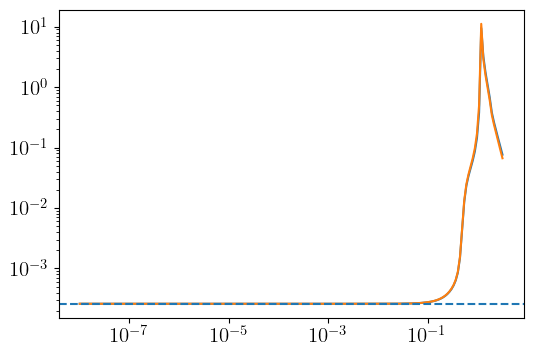

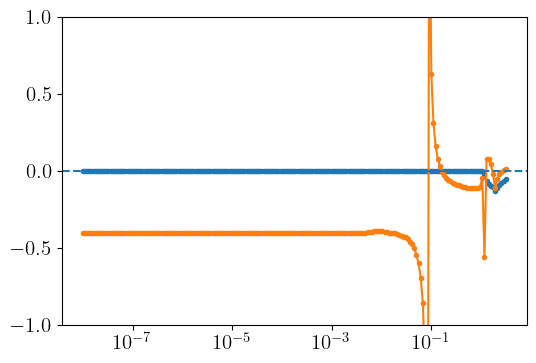

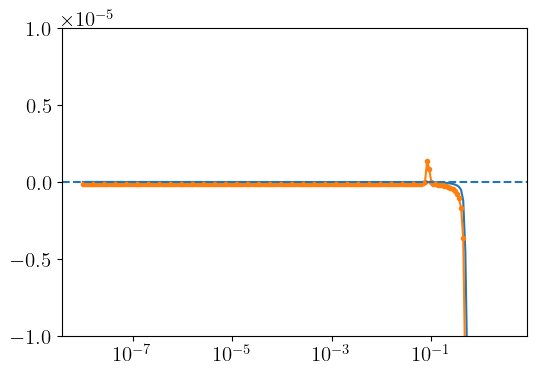

In [57]:
m3, m6, m4a, m4b = compute_all_mf_matrices(m.K, m.rho, m.geom, m.phases, m.g_ffts)
mat = m3 + m6 + m4a + m4b
mat_tilde = operator_tilde(mat, m.vecs)

i = 0
chi_UV(Nk, mat_tilde, rhos_tilde[i], Pi_w[5], Pi_eps_w[5])

Gamma = 0.008
epsilons = np.linspace(-3,3,1000)
mfd1 = -fd_1(epsilons, m.Ts[-1])
l11, l12, l22, l12q = m.ls_kubo(epsilons, Gamma, mfd1)

plt.plot(omegas, Chi_jj0.imag / omegas)
plt.plot(omegas, (Chi_jj0 + dChi_jj).imag / omegas)
plt.axhline(l11, ls='dashed')
plt.yscale('log')
plt.xscale('log')

plt.show()

plt.plot(omegas, Chi_jEj0.imag / omegas, '.-')
plt.plot(omegas, (Chi_jEj0 + dChi_jEj).imag / omegas, '.-')
plt.axhline(l12, ls='dashed')
plt.ylim(-1.0,1.0)
plt.xscale('log')

plt.show()

plt.plot(omegas, Chi_matj0.imag / omegas)
plt.plot(omegas, (Chi_matj0 + dChi_matj).imag / omegas, '.-')
plt.axhline(l12q, ls='dashed')
plt.ylim(-1e-5,1e-5)
plt.xscale('log')
plt.show()

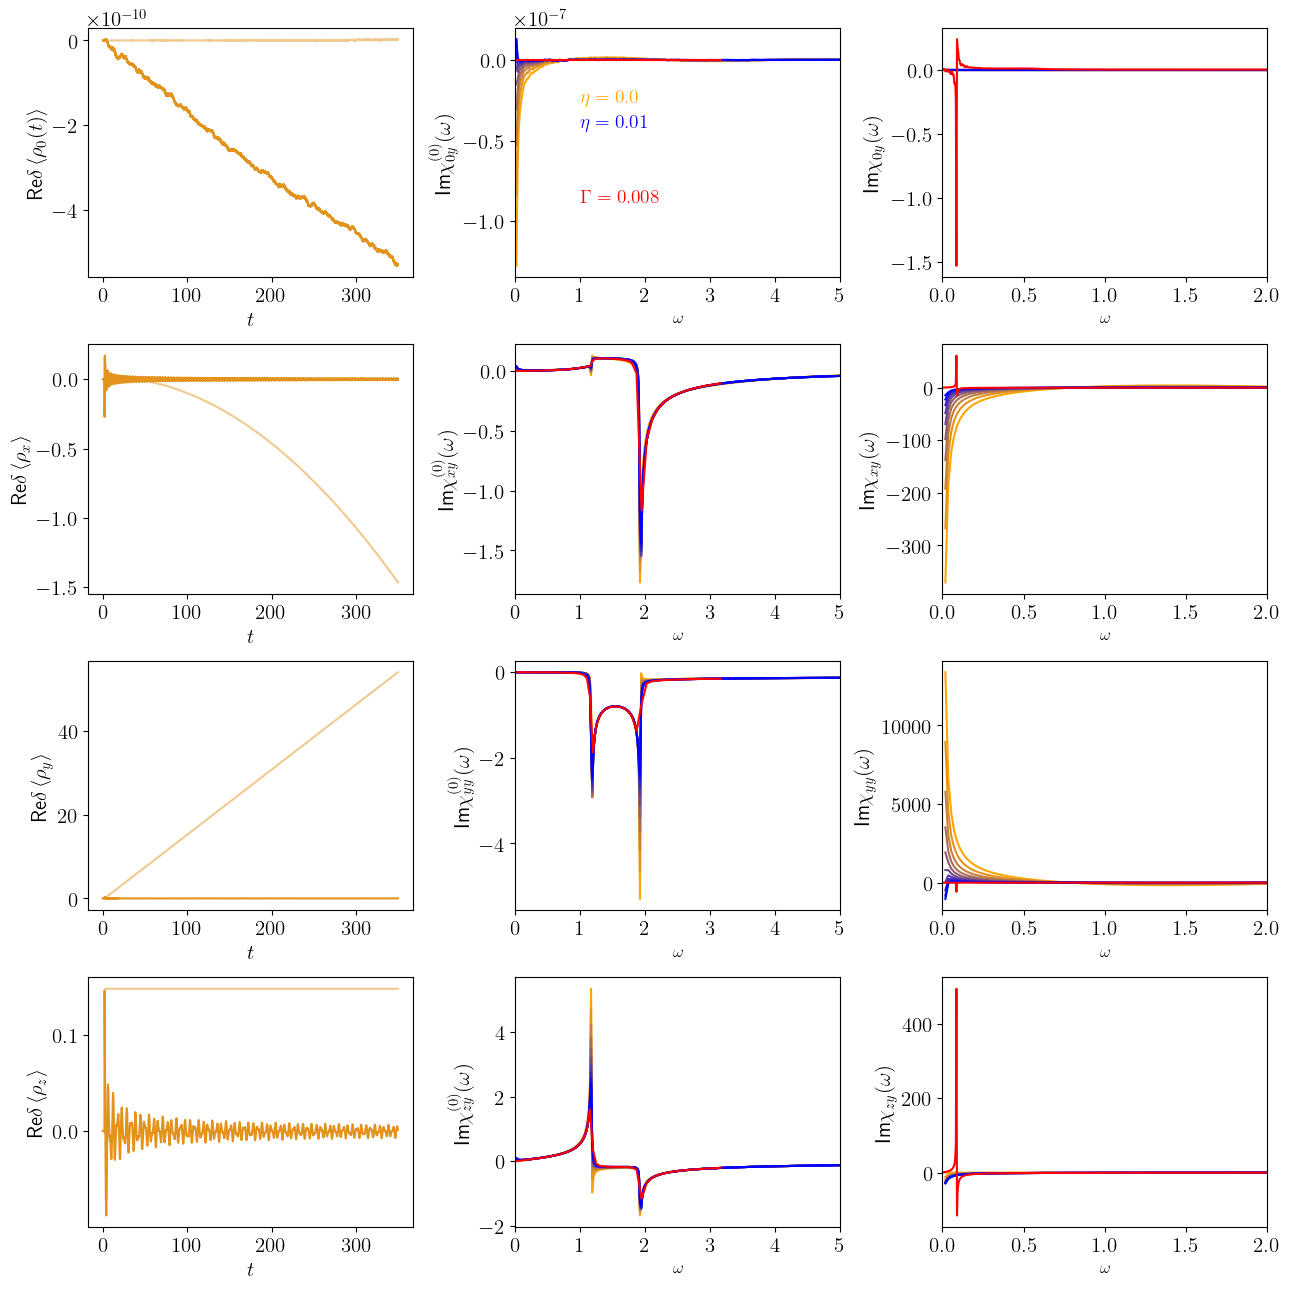

In [50]:
etas = np.linspace(0,1e-2,10)
pulz = A_pulz(time, A0, t0, sigma, Omega0)
omega_cut = 5
#omegas = np.linspace(0.01,5.0,500)


parities = [1, 1, -1, 1, 1, 1, -1, 1]

fig, ax = plt.subplots(ncols=3, nrows=4, figsize=(13,13))
for i, eta in enumerate(etas):
    col = colorFader('orange', 'blue', i / (len(etas) - 1))
    for j in range(4):
        meas = measurement[j] - measurement[j,0]
        measN = measurementN[j] - measurementN[j,0]

        Omega, Signal_, Pulz = susceptibility(time, meas, pulz, eta, omega_cut, m.Nk)
        _, Signal_N, _ = susceptibility(timeN, measN, pulz, eta, omega_cut, m.Nk)
        Chi_ = Signal_ / Pulz
        Chi_N = Signal_N / Pulz

        if i ==1:
            ax[j,0].plot(time, meas.real, color=col, zorder=10)
            ax[j,0].plot(time, measN.real, color=colorFader(col, 'white', 0.5))
        ax[j,1].plot(Omega, Chi_.imag, color=col)
        ax[j,2].plot(Omega, Chi_N.imag, color=col)

for j in range(4):
    chi0 = Chi0[j,2]
    chi = Chi_full[j,2]
    eps = parities[j]
    ax[j,1].plot(omegas, eps * chi0.imag, color='red')
    ax[j,2].plot(omegas, eps * chi.imag, color='red')


for i in range(4):
    for j in range(1,3):
        ax[i,j].set_xlabel('$\omega$', fontsize=12)
        ax[i,j].set_xlim(0,5.0)

ax[0,1].set_ylabel(r'$\text{Im}\chi_{0y}^{(0)}(\omega)$', fontsize=15)
ax[1,1].set_ylabel(r'$\text{Im}\chi_{xy}^{(0)}(\omega)$', fontsize=15)
ax[0,2].set_ylabel(r'$\text{Im}\chi_{yy}(\omega)$', fontsize=15)
ax[1,2].set_ylabel(r'$\text{Im}\chi_{zy}(\omega)$', fontsize=15)


ax[2,1].set_ylabel(r'$\text{Im}\chi_{0y}^{(0)}(\omega)$', fontsize=15)
ax[3,1].set_ylabel(r'$\text{Im}\chi_{zy}^{(0)}(\omega)$', fontsize=15)
ax[2,2].set_ylabel(r'$\text{Im}\chi_{0y}(\omega)$', fontsize=15)
ax[3,2].set_ylabel(r'$\text{Im}\chi_{zy}(\omega)$', fontsize=15)

ax[0,1].text(0.2, 0.7, rf'$\eta = {np.round(etas[0],5)}$', transform=ax[0,1].transAxes, color='orange', fontsize=14)
ax[0,1].text(0.2, 0.6, rf'$\eta = {np.round(etas[-1],5)}$', transform=ax[0,1].transAxes, color='blue', fontsize=14)
ax[0,1].text(0.2,0.3, rf'$\Gamma={Gamma}$', transform=ax[0,1].transAxes, color='red', fontsize=14)
for j in range(4):
    ax[j,0].set_xlabel(r'$t$', fontsize=15)

ax[0,0].set_ylabel(r'$\text{Re} \delta \expval{\rho_0(t)}$', fontsize=15)
ax[1,0].set_ylabel(r'$\text{Re}\delta  \expval{\rho_x}$', fontsize=15)
ax[2,0].set_ylabel(r'$\text{Re}\delta  \expval{\rho_y}$', fontsize=15)
ax[3,0].set_ylabel(r'$\text{Re}\delta  \expval{\rho_z}$', fontsize=15)

ax[0,1].set_ylabel(r'$\text{Im}\chi_{0y}^{(0)}(\omega)$', fontsize=15)
ax[1,1].set_ylabel(r'$\text{Im}\chi_{xy}^{(0)}(\omega)$', fontsize=15)
ax[2,1].set_ylabel(r'$\text{Im}\chi_{yy}^{(0)}(\omega)$', fontsize=15)
ax[3,1].set_ylabel(r'$\text{Im}\chi_{zy}^{(0)}(\omega)$', fontsize=15)

ax[0,2].set_ylabel(r'$\text{Im}\chi_{0y}(\omega)$', fontsize=15)
ax[1,2].set_ylabel(r'$\text{Im}\chi_{xy}(\omega)$', fontsize=15)
ax[2,2].set_ylabel(r'$\text{Im}\chi_{yy}(\omega)$', fontsize=15)
ax[3,2].set_ylabel(r'$\text{Im}\chi_{zy}(\omega)$', fontsize=15)


for j in range(4):
    ax[j,2].set_xlim(0,2)

plt.tight_layout()

plt.savefig('slika1.pdf')

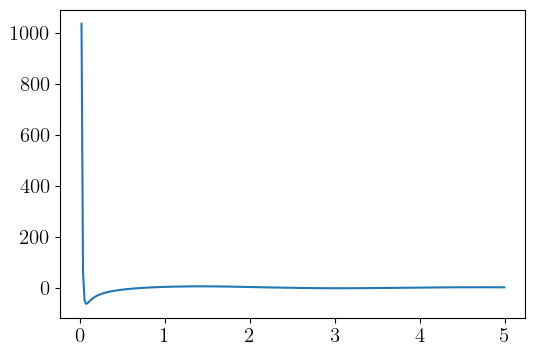

In [51]:
j = 2

meas = measurement[j] - measurement[j,0]
measN = measurementN[j] - measurementN[j,0]

Omega, Signal_, Pulz = susceptibility(time, meas, pulz, eta, omega_cut, m.Nk)
_, Signal_N, _ = susceptibility(timeN, measN, pulz, eta, omega_cut, m.Nk)
Chi_ = Signal_ / Pulz
Chi_N = Signal_N / Pulz

plt.plot(Omega, -Chi_N.imag)
#plt.ylim(0,1)

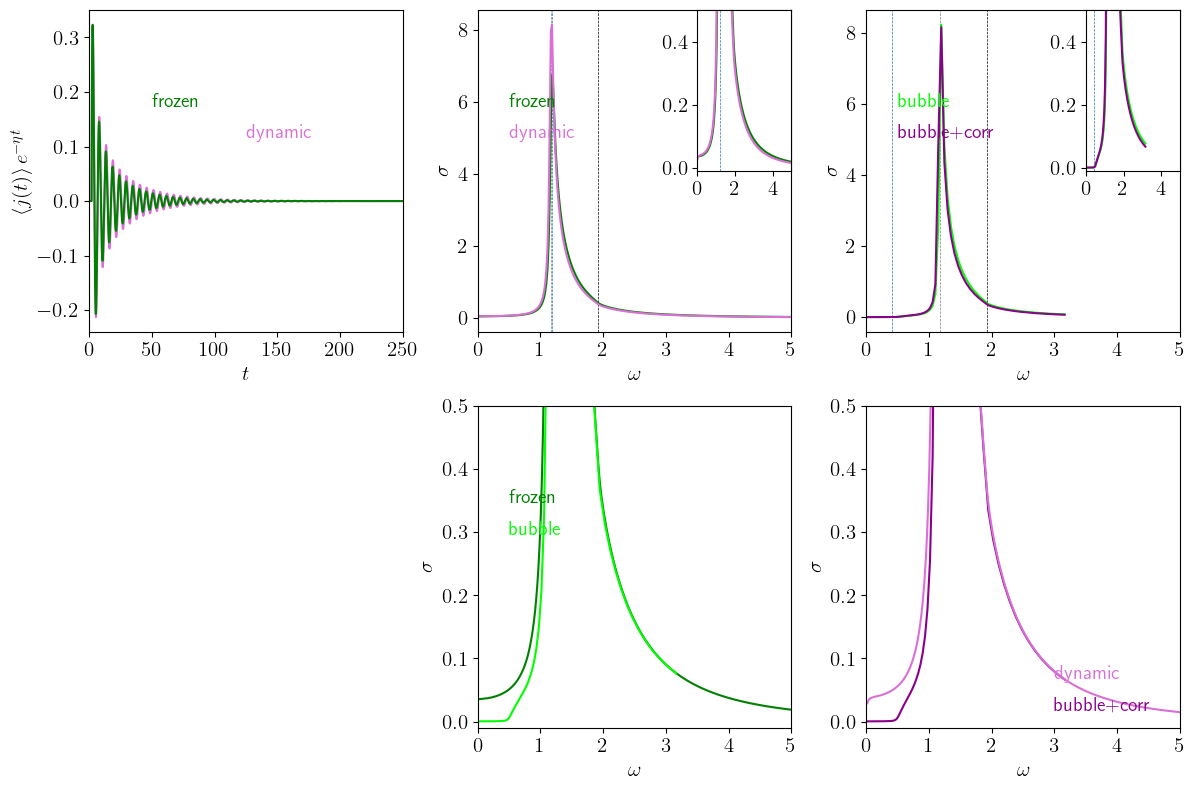

In [52]:
fig, ax = plt.subplots(ncols=3, nrows=2, figsize=(12,8))
gap = np.min(m.energije[1]) - np.max(m.energije[0])

measJ = measurementJ[0].real - measurementJ[0,0].real
measNJ = measurementNJ[0].real - measurementNJ[0,0].real

pulz = A_pulz(timeJ, A0, t0, sigma, Omega0)
omega_cut = 5
eta = 0.03

Omega, Sigma = optical_conductivity(timeJ, measJ, pulz, eta, omega_cut, m.Nk)
_, SigmaN = optical_conductivity(timeJ, measNJ, pulz, eta, omega_cut, m.Nk)

ins1 = ax[0,1].inset_axes([0.7,0.5,0.3,0.5])
ins2 = ax[0,2].inset_axes([0.7,0.5,0.3,0.5])

ax[0,0].plot(timeNJ, measJ * np.exp(-eta * timeNJ), color='green', label='frozen')
ax[0,0].plot(timeNJ, measNJ * np.exp(-eta * timeNJ), color='orchid', zorder=-100, label='dynamic')

ax[0,1].plot(Omega, Sigma, color='green'), ins1.plot(Omega, Sigma, color='green')
ax[1,1].plot(Omega, Sigma, color='green')

ax[0,1].plot(Omega, SigmaN, color='orchid'), ins1.plot(Omega, SigmaN, color='orchid')
ax[1,2].plot(Omega, SigmaN, color='orchid')
ins1.set_ylim(-0.01,0.5)

ax[0,2].plot(omegas, Chi_jj0.imag / omegas, color='lime'), ins2.plot(omegas, Chi_jj0.imag / omegas, color='lime')
ax[1,1].plot(omegas, Chi_jj0.imag / omegas, color='lime')
ax[0,2].plot(omegas, dChi_jj.imag / omegas + Chi_jj0.imag / omegas, color='darkmagenta'), ins2.plot(omegas, dChi_jj.imag / omegas + Chi_jj0.imag / omegas, color='darkmagenta')
ax[1,2].plot(omegas, dChi_jj.imag / omegas + Chi_jj0.imag / omegas, zorder=-100, color='darkmagenta')
ins2.set_ylim(-0.01,0.5)

ax[0,0].set_xlabel(r'$t$', fontsize=15)
ax[0,0].set_ylabel(r'$\expval{j(t)}e^{-\eta t}$', fontsize=15)
for i in range(2):
    ax[0,1+i].set_xlabel(r'$\omega$', fontsize=15)
    ax[1,1+i].set_xlabel(r'$\omega$', fontsize=15)
    ax[0,1+i].set_xlim(0,5)
    ax[1,1+i].set_xlim(0,5)
ax[0,0].set_xlim(0,250)

omega_max1 = Omega[np.argmax(SigmaN[:100])]
omega_max2 = Omega[np.argmax(SigmaN)]

omega_max1_ = omegas[np.argmax((dChi_jj.imag / omegas + Chi_jj0.imag / omegas)[:150])]
omega_max2_ = omegas[np.argmax((dChi_jj.imag / omegas + Chi_jj0.imag / omegas))]

ax[0,1].axvline(omega_max1, ls='dashed', zorder=-100, lw=0.5), ins1.axvline(omega_max1, ls='dashed', zorder=-100, lw=0.5)

ax[0,2].axvline(omega_max1_, ls='dashed', zorder=-100, lw=0.5), ins2.axvline(omega_max1_, ls='dashed', zorder=-100, lw=0.5)

for j in range(1,3):
    ax[0,j].axvline(dE_1, color='grey', ls='dashed', zorder=-100, lw=0.5)
    ax[0,j].axvline(dE_2, color='black', ls='dashed', zorder=-100, lw=0.5)

for j in range(2):
    for i in range(1,3):
        ax[j,i].set_ylabel(r'$\sigma$', fontsize=15)

ax[1,2].set_ylim(-0.01,0.5)
ax[1,1].set_ylim(-0.01,0.5)
ins1.set_xlim(0,5), ins2.set_xlim(0,5)

ax[0,0].text(0.2, 0.7, rf'frozen', transform=ax[0,0].transAxes, color='green', fontsize=14)
ax[0,0].text(0.5, 0.6, rf'dynamic', transform=ax[0,0].transAxes, color='orchid', fontsize=14)

ax[0,1].text(0.1, 0.7, rf'frozen', transform=ax[0,1].transAxes, color='green', fontsize=14)
ax[0,1].text(0.1, 0.6, rf'dynamic', transform=ax[0,1].transAxes, color='orchid', fontsize=14)

ax[0,2].text(0.1, 0.7, rf'bubble', transform=ax[0,2].transAxes, color='lime', fontsize=14)
ax[0,2].text(0.1, 0.6, rf'bubble+corr', transform=ax[0,2].transAxes, color='darkmagenta', fontsize=14)

ax[1,1].text(0.1,0.7, rf'frozen', transform=ax[1,1].transAxes, color='green', fontsize=14)
ax[1,1].text(0.1,0.6, rf'bubble', transform=ax[1,1].transAxes, color='lime', fontsize=14)

ax[1,2].text(0.6,0.15, rf'dynamic', transform=ax[1,2].transAxes, color='orchid', fontsize=14)
ax[1,2].text(0.6,0.05, rf'bubble+corr', transform=ax[1,2].transAxes, color='darkmagenta', fontsize=14)

ins1.set_xticks([0,2,4]), ins2.set_xticks([0,2,4])
ax[1,0].axis('off')
plt.tight_layout()
plt.savefig('slika2.pdf')